###Installing the neccessary libraries

In [ ]:
!pip install tensorflow
!pip install numpy
!pip install matplotlib

###Import the Libraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models
from tensorflow.keras.utils import to_categorical

###Loading the Dataset

In [ ]:
dataset=tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Yawn-detection-dataset"
    ,image_size=(128,128)
    ,batch_size=32
)
class_names=dataset.class_names
print(class_names)

Found 5119 files belonging to 2 classes.
['no yawn', 'yawn']


###Image Preprocess

In [ ]:
dataset=dataset.map(lambda images,labels:(tf.cast(images,tf.float32)/255,labels))

###Model Defining

In [ ]:
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dense(1,activation="sigmoid")
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

###Optimizer and Loss

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

###Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

###Model Training

In [ ]:
history=model.fit(
    dataset,
    epochs=10,
    validation_data=dataset,
    callbacks=[early_stopping]
)

Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 560s 4s/step - accuracy: 0.9027 - loss: 3.7148 - val_accuracy: 0.9432 - val_loss: 0.1642
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.9533 - loss: 0.1429 - val_accuracy: 0.9658 - val_loss: 0.1198
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.9701 - loss: 0.0968 - val_accuracy: 0.9807 - val_loss: 0.0598
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.9777 - loss: 0.0748 - val_accuracy: 0.9842 - val_loss: 0.0490
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 295s 2s/step - accuracy: 0.9791 - loss: 0.0646 - val_accuracy: 0.9691 - val_loss: 0.0858
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.9768 - loss: 0.0672 - val_accuracy: 0.9764 - val_loss: 0.0714
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.9828 - loss: 0.0631 - val_accuracy: 0.9838 - val_loss: 0.0483
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.9853 - loss: 0.0504 - val_accu

###Model Evaluation

In [ ]:
test_loss,test_acc=model.evaluate(dataset)
print(f"Test Accuracy: {test_acc*100:.2f}%")

160/160 ━━━━━━━━━━━━━━━━━━━━ 64s 396ms/step - accuracy: 0.9924 - loss: 0.0247
Test Accuracy: 99.24%


###Model Loss and Accuracy

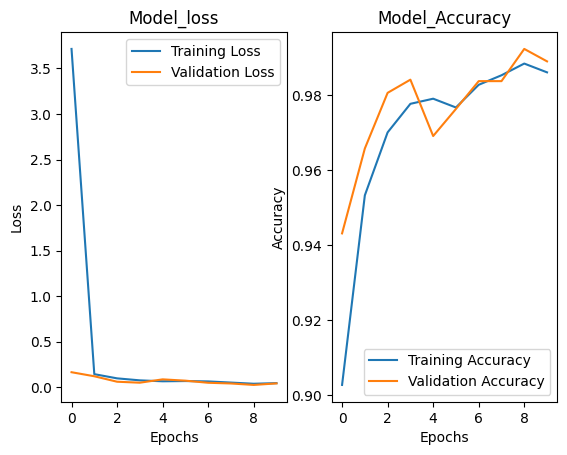

In [ ]:
plt.subplot(1,2,1)
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.title("Model_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.title("Model_Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

###Model Saving

In [ ]:
model.save("/content/drive/MyDrive/CNN_Yawn_classifier.keras")

###Testing the Model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


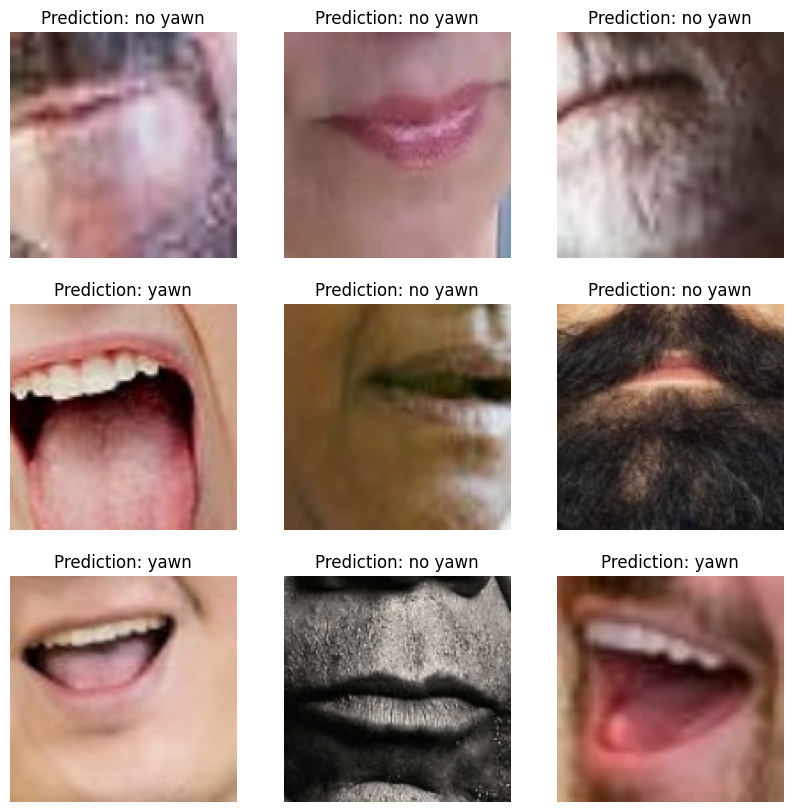

In [ ]:
for images,labels in dataset.take(1):
  plt.figure(figsize=(10,10))
  for i in range(9):
    predictions=model.predict(tf.expand_dims(images[i],axis=0))
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(f"Prediction: {class_names[int(tf.round(predictions[0][0]))]}")
    plt.axis("off")